In [1]:
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

In [18]:
class GreetState(BaseModel):
    message: str = ""

In [27]:
graph = StateGraph(GreetState)

In [28]:
## Nodes - Python functions
def Greet(state: GreetState):
    state.message = f"{state.message} ! All Good !"
    return state

def upperCase(state: GreetState):
    state.message = state.message.upper()
    return state

In [29]:
graph.add_node("greet", Greet)
graph.add_node("upper_case", upperCase)

In [30]:
graph.add_edge(START, "greet")
graph.add_edge("greet", "upper_case")
graph.add_edge("upper_case", END)

In [31]:
finalGraph = graph.compile()

In [32]:
res = finalGraph.invoke({"message":"I love langgraph"})

In [33]:
res

{'message': 'I LOVE LANGGRAPH ! ALL GOOD !'}

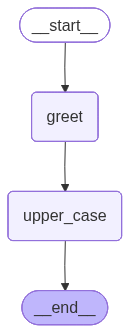

In [34]:
from IPython.display import Image
Image(finalGraph.get_graph().draw_mermaid_png())